# Predicting Airline Satisfaction
## Score: .95852

## Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("playground-series-s6e10/train.csv")
test = pd.read_csv("playground-series-s6e10/test.csv")
sample_submission = pd.read_csv("playground-series-s6e10/sample_submission.csv")

## EDA

In [2]:
display(train.shape, test.shape)
display(train.head())
display(train.dtypes)
display(train.describe(include="all").T)
display(train.isna().sum())
display(test.isna().sum())
display(train["satisfaction"].value_counts(normalize=True))

cat_cols = train.select_dtypes(include=["object", "string", "bool"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "satisfaction"]
for col in cat_cols:
    display(col, train[col].value_counts())

(699635, 23)

(299844, 22)

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


id                                     int64
Age                                    int64
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Gender                                object
Customer Type                         object
Type of Travel                        object
Class                                 object
satisfacti

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,699635.0,NaN,NaN,NaN,349817.0,201967.37213,0.0,174908.5,349817.0,524725.5,699634.0
Age,699635.0,NaN,NaN,NaN,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,NaN,NaN,NaN,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Inflight wifi service,699635.0,NaN,NaN,NaN,2.778722,1.280419,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,699635.0,NaN,NaN,NaN,3.15621,1.47539,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,699635.0,NaN,NaN,NaN,2.81324,1.32955,0.0,2.0,3.0,4.0,5.0
Gate location,699635.0,NaN,NaN,NaN,3.013734,1.254014,0.0,2.0,3.0,4.0,5.0
Food and drink,699635.0,NaN,NaN,NaN,3.265644,1.300202,0.0,2.0,3.0,4.0,5.0
Online boarding,699635.0,NaN,NaN,NaN,3.364156,1.288538,0.0,2.0,4.0,4.0,5.0
Seat comfort,699635.0,NaN,NaN,NaN,3.56895,1.275333,0.0,3.0,4.0,5.0,5.0


...

Customer Type
Loyal Customer       576990
disloyal Customer    122645
Name: count, dtype: int64

'Type of Travel'

Type of Travel
Business travel    497441
Personal Travel    202194
Name: count, dtype: int64

'Class'

Class
Business    342212
Eco         327404
Eco Plus     30019
Name: count, dtype: int64

## Feature Distributions

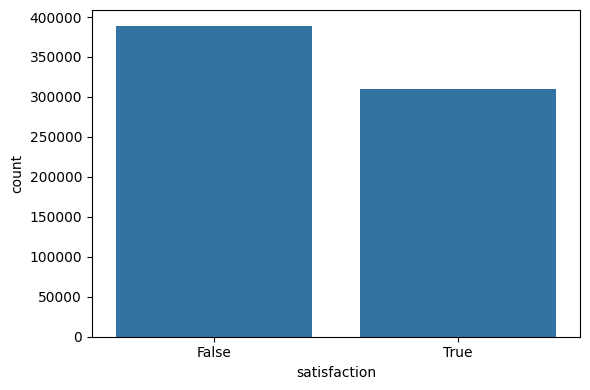

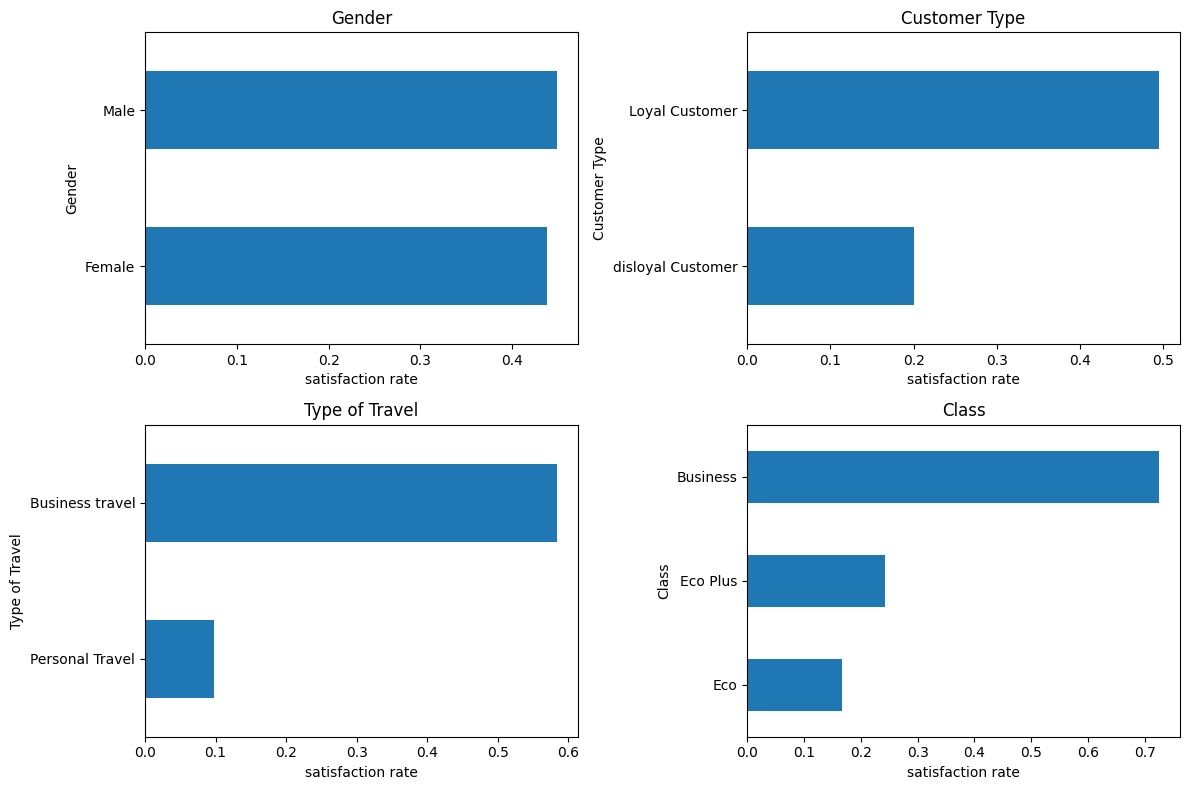

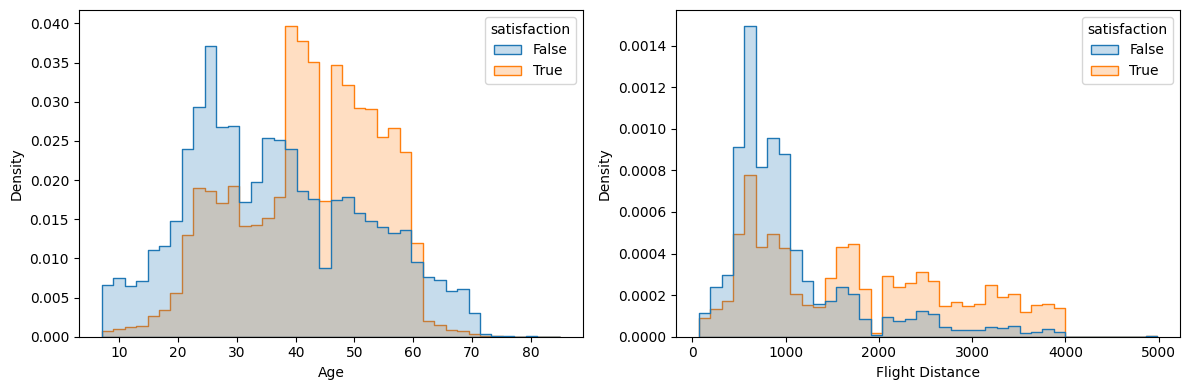

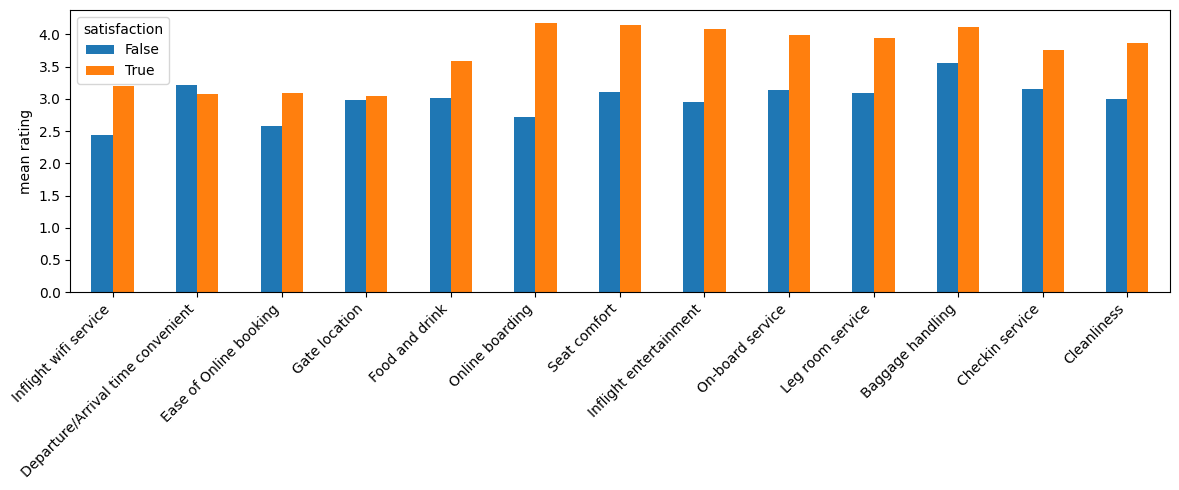

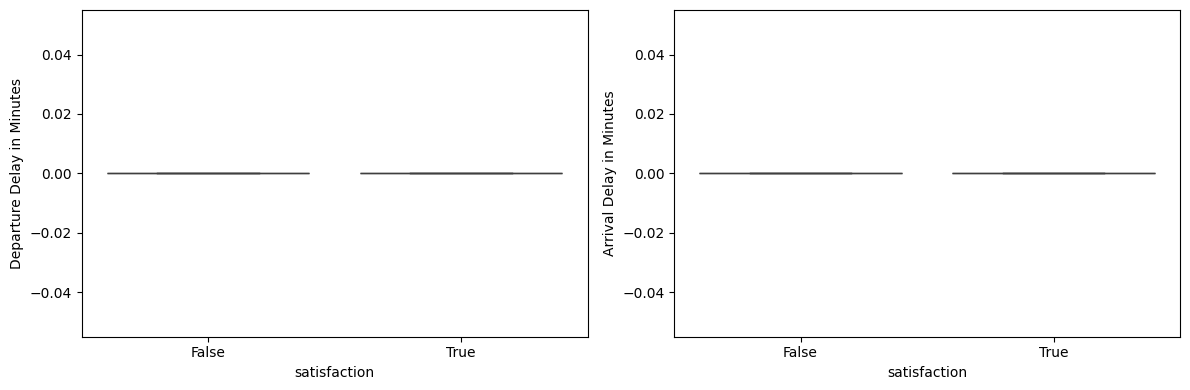

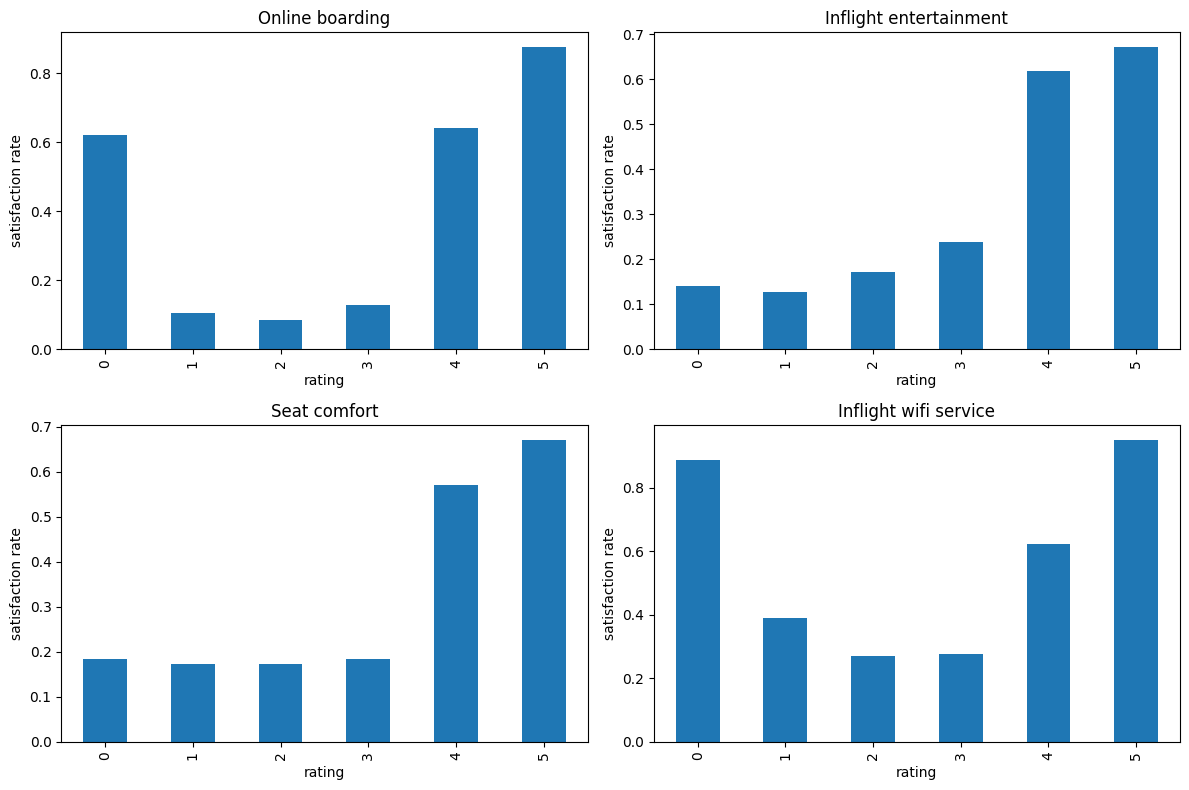

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train, x="satisfaction", ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = train.groupby(col, observed=True)["satisfaction"].mean().sort_values()
    rate.plot(kind="barh", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("satisfaction rate")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Age", "Flight Distance"]):
    sns.histplot(data=train, x=col, hue="satisfaction", bins=40, element="step", common_norm=False, stat="density", ax=ax)
plt.tight_layout()
plt.show()

rating_cols = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness",
]

rating_means = train.groupby("satisfaction", observed=True)[rating_cols].mean().T
rating_means.plot(kind="bar", figsize=(12, 5))
plt.ylabel("mean rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Departure Delay in Minutes", "Arrival Delay in Minutes"]):
    sns.boxplot(data=train, x="satisfaction", y=col, ax=ax, showfliers=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["Online boarding", "Inflight entertainment", "Seat comfort", "Inflight wifi service"]):
    rate = train.groupby(col, observed=True)["satisfaction"].mean()
    rate.plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("satisfaction rate")
    ax.set_xlabel("rating")
plt.tight_layout()
plt.show()

## Correlation Matrix

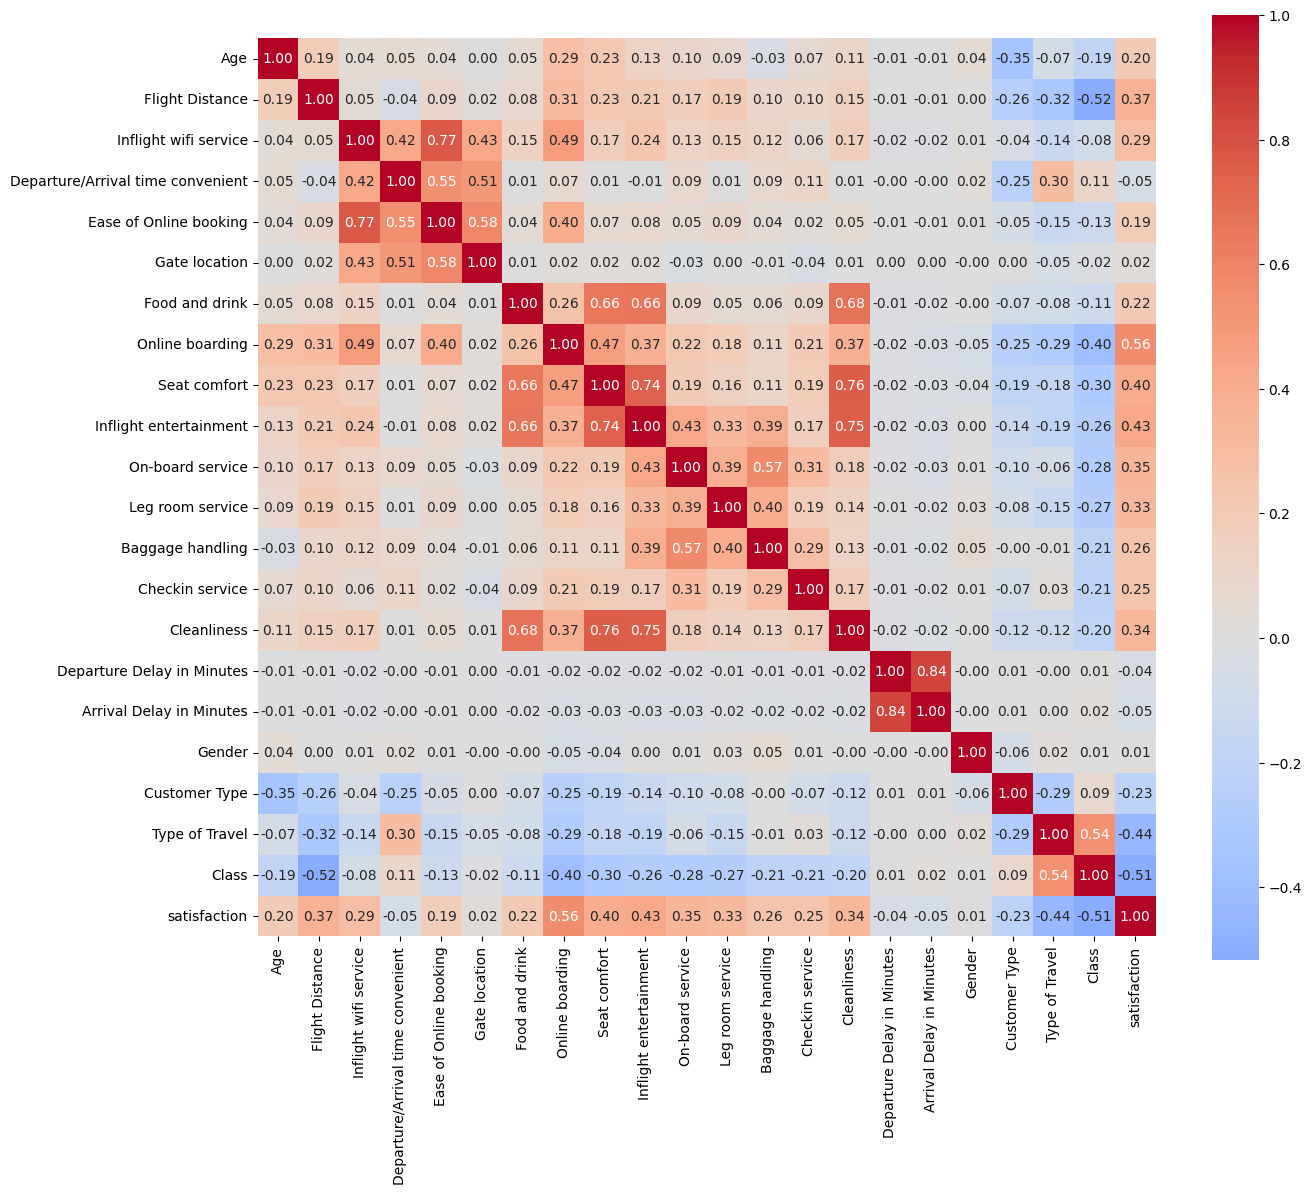

satisfaction                         1.000000
Online boarding                      0.559583
Inflight entertainment               0.430755
Seat comfort                         0.401488
Flight Distance                      0.370038
On-board service                     0.346618
Cleanliness                          0.338853
Leg room service                     0.330116
Inflight wifi service                0.291275
Baggage handling                     0.258118
Checkin service                      0.249799
Food and drink                       0.218058
Age                                  0.202708
Ease of Online booking               0.190878
Gate location                        0.022834
Gender                               0.011169
Departure Delay in Minutes          -0.035815
Departure/Arrival time convenient   -0.049185
Arrival Delay in Minutes            -0.051641
Customer Type                       -0.225161
Type of Travel                      -0.444418
Class                             

In [4]:
corr_df = train.drop(columns=["id"]).copy()
corr_df["satisfaction"] = corr_df["satisfaction"].astype(int)
for col in cat_cols:
    corr_df[col] = corr_df[col].astype("category").cat.codes

corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.tight_layout()
plt.show()

display(corr["satisfaction"].sort_values(ascending=False))

## Preprocessing

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize
from scipy.special import expit, logit
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

TARGET = "satisfaction"
ID_COL = "id"
CAT_COLS = ["Gender", "Customer Type", "Type of Travel", "Class"]
RATING_COLS = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness",
]
INTER_COLS = ["travel_class", "cust_travel", "cust_class"]
SEG_COLS = ["class_wifi", "travel_board", "class_board", "cust_wifi"]
TE_COLS = CAT_COLS + INTER_COLS
FEATURE_COLS = [c for c in train.columns if c not in [ID_COL, TARGET]]


def prepare_features(df, inter=False, seg=False, ratings_as_cat=False):
    out = df[FEATURE_COLS].copy()
    out["Arrival Delay in Minutes"] = out["Arrival Delay in Minutes"].fillna(
        out["Departure Delay in Minutes"]
    )
    ratings = out[RATING_COLS]
    out["rating_mean"] = ratings.mean(axis=1)
    out["rating_std"] = ratings.std(axis=1)
    out["rating_min"] = ratings.min(axis=1)
    out["rating_max"] = ratings.max(axis=1)
    out["rating_sum"] = ratings.sum(axis=1)
    out["n_zero_rating"] = (ratings == 0).sum(axis=1)
    out["n_low_rating"] = ((ratings >= 1) & (ratings <= 2)).sum(axis=1)
    out["n_high_rating"] = (ratings >= 4).sum(axis=1)
    out["total_delay"] = (
        out["Departure Delay in Minutes"] + out["Arrival Delay in Minutes"]
    )
    out["delay_diff"] = (
        out["Arrival Delay in Minutes"] - out["Departure Delay in Minutes"]
    )
    out["is_delayed"] = (out["total_delay"] > 0).astype(int)
    cat_cols = list(CAT_COLS)
    if inter or seg:
        out["travel_class"] = (
            out["Type of Travel"].astype(str) + "|" + out["Class"].astype(str)
        ).astype("category")
        out["cust_travel"] = (
            out["Customer Type"].astype(str) + "|" + out["Type of Travel"].astype(str)
        ).astype("category")
        out["cust_class"] = (
            out["Customer Type"].astype(str) + "|" + out["Class"].astype(str)
        ).astype("category")
        cat_cols = cat_cols + INTER_COLS
    if seg:
        out["class_wifi"] = (
            out["Class"].astype(str)
            + "|"
            + out["Inflight wifi service"].astype(int).astype(str)
        ).astype("category")
        out["travel_board"] = (
            out["Type of Travel"].astype(str)
            + "|"
            + out["Online boarding"].astype(int).astype(str)
        ).astype("category")
        out["class_board"] = (
            out["Class"].astype(str)
            + "|"
            + out["Online boarding"].astype(int).astype(str)
        ).astype("category")
        out["cust_wifi"] = (
            out["Customer Type"].astype(str)
            + "|"
            + out["Inflight wifi service"].astype(int).astype(str)
        ).astype("category")
        cat_cols = cat_cols + SEG_COLS
    if ratings_as_cat:
        cat_cols = cat_cols + RATING_COLS
    for col in cat_cols:
        out[col] = out[col].astype("category")
    return out, cat_cols


def add_target_encoding(X_train, X_test, y_train, cols, folds):
    X_tr = X_train.copy()
    X_te = X_test.copy()
    global_mean = float(y_train.mean())
    for col in cols:
        oof = np.zeros(len(X_train))
        test_acc = np.zeros(len(X_test))
        keys_tr = X_train[col].astype(str)
        keys_te = X_test[col].astype(str)
        for tr_idx, va_idx in folds:
            tmp = pd.DataFrame({"k": keys_tr.iloc[tr_idx].values, "y": y_train.iloc[tr_idx].values})
            means = tmp.groupby("k")["y"].mean()
            oof[va_idx] = keys_tr.iloc[va_idx].map(means).fillna(global_mean).astype(float).values
            test_acc += keys_te.map(means).fillna(global_mean).astype(float).values / len(folds)
        X_tr[col + "_te"] = oof
        X_te[col + "_te"] = test_acc
    return X_tr, X_te


def add_frequency_encoding(X_train, X_test, cols):
    X_tr = X_train.copy()
    X_te = X_test.copy()
    for col in cols:
        vc = pd.concat([X_tr[col], X_te[col]], axis=0).astype(str).value_counts()
        X_tr[col + "_freq"] = X_tr[col].astype(str).map(vc).astype(float)
        X_te[col + "_freq"] = X_te[col].astype(str).map(vc).astype(float)
    return X_tr, X_te


y = train[TARGET].astype(int)
X, _ = prepare_features(train, inter=False, ratings_as_cat=False)
X_test, _ = prepare_features(test, inter=False, ratings_as_cat=False)
X_cat, _ = prepare_features(train, inter=False, ratings_as_cat=True)
X_test_cat, _ = prepare_features(test, inter=False, ratings_as_cat=True)
X_inter, cat_cols_inter = prepare_features(train, inter=True, ratings_as_cat=False)
X_test_inter, _ = prepare_features(test, inter=True, ratings_as_cat=False)
X_seg, cat_cols_seg = prepare_features(train, inter=True, seg=True, ratings_as_cat=False)
X_test_seg, _ = prepare_features(test, inter=True, seg=True, ratings_as_cat=False)
X_allcat, cat_cols_allcat = prepare_features(train, inter=True, seg=True, ratings_as_cat=True)
X_test_allcat, _ = prepare_features(test, inter=True, seg=True, ratings_as_cat=True)
X_freq, X_test_freq = add_frequency_encoding(X_seg, X_test_seg, cat_cols_seg)

display(X.shape, X_cat.shape, X_inter.shape, X_seg.shape, X_allcat.shape, X_freq.shape, X_test.shape)
display(y.value_counts(normalize=True))
display(X.isna().sum().sum(), X_test.isna().sum().sum())


(699635, 32)

(699635, 32)

(699635, 35)

(699635, 39)

(699635, 39)

(699635, 50)

(299844, 32)

satisfaction
0    0.556427
1    0.443573
Name: proportion, dtype: float64

np.int64(0)

np.int64(0)

## Model

In [6]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
folds = list(skf.split(X, y))

X_te, X_test_te = add_target_encoding(X_inter, X_test_inter, y, TE_COLS, folds)
te_feature_cols = [c + "_te" for c in TE_COLS]
display(X_te.shape, X_test_te[te_feature_cols].head())

xgb_params_a = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 7,
    "learning_rate": 0.04,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 5,
    "reg_lambda": 1.5,
    "max_cat_to_onehot": 4,
}
xgb_params_b = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 8,
    "learning_rate": 0.03,
    "subsample": 0.9,
    "colsample_bytree": 0.75,
    "min_child_weight": 3,
    "reg_lambda": 1.5,
    "reg_alpha": 0.1,
    "max_cat_to_onehot": 4,
}
xgb_params_shallow = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 4,
    "learning_rate": 0.06,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "min_child_weight": 10,
    "reg_lambda": 2.0,
    "max_cat_to_onehot": 4,
}
lgb_param_list = [
    {
        "name": "lgb_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.05,
            "num_leaves": 64,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_child_samples": 40,
            "verbosity": -1,
            "seed": 42,
        },
        "data": "inter",
    },
    {
        "name": "lgb2_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.035,
            "num_leaves": 96,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_child_samples": 25,
            "verbosity": -1,
            "seed": 7,
            "bagging_seed": 7,
            "feature_fraction_seed": 7,
        },
        "data": "inter",
        "seeds": [7, 17, 27],
    },
    {
        "name": "lgb3_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.03,
            "num_leaves": 48,
            "feature_fraction": 0.7,
            "bagging_fraction": 0.7,
            "bagging_freq": 1,
            "min_child_samples": 60,
            "verbosity": -1,
            "seed": 99,
            "bagging_seed": 99,
            "feature_fraction_seed": 99,
        },
        "data": "inter",
        "seeds": [99, 199, 299, 399],
    },
    {
        "name": "lgb_seg",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.035,
            "num_leaves": 96,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_child_samples": 25,
            "verbosity": -1,
            "seed": 13,
            "bagging_seed": 13,
            "feature_fraction_seed": 13,
        },
        "data": "seg",
        "seeds": [13, 113, 213],
    },
    {
        "name": "lgb_freq",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.035,
            "num_leaves": 96,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_child_samples": 25,
            "verbosity": -1,
            "seed": 31,
            "bagging_seed": 31,
            "feature_fraction_seed": 31,
        },
        "data": "freq",
        "seeds": [31, 131],
    },
    {
        "name": "lgb_te",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.03,
            "num_leaves": 80,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "min_child_samples": 30,
            "verbosity": -1,
            "seed": 21,
            "bagging_seed": 21,
            "feature_fraction_seed": 21,
        },
        "data": "te",
    },
    {
        "name": "lgb_goss",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "boosting_type": "goss",
            "learning_rate": 0.03,
            "num_leaves": 72,
            "feature_fraction": 0.85,
            "top_rate": 0.2,
            "other_rate": 0.1,
            "min_child_samples": 35,
            "verbosity": -1,
            "seed": 11,
        },
        "data": "te",
    },
]

model_names = (
    ["xgb_a", "xgb_b", "xgb_int", "xgb_seg", "xgb_shallow", "xgb_te"]
    + [cfg["name"] for cfg in lgb_param_list]
    + ["lgb_travel", "lgb_class", "cb_cat", "cb_rs"]
)
oof = {name: np.zeros(len(X)) for name in model_names}
test_oof = {name: np.zeros(len(X_test)) for name in model_names}
fold_scores = {name: [] for name in model_names}
xgb_models_a, xgb_models_b, xgb_models_int, xgb_models_seg, xgb_models_shallow, xgb_models_te = (
    [],
    [],
    [],
    [],
    [],
    [],
)
lgb_models = {cfg["name"]: [] for cfg in lgb_param_list}
lgb_travel_models = []
lgb_class_models = []
cb_cat_models = []
cb_rs_models = []

data_map = {
    "inter": (X_inter, X_test_inter, cat_cols_inter),
    "seg": (X_seg, X_test_seg, cat_cols_seg),
    "freq": (X_freq, X_test_freq, cat_cols_seg),
    "te": (X_te, X_test_te, cat_cols_inter),
}


def fit_segment_lgb(X_frame, X_test_frame, cats, tr_idx, va_idx, col):
    keys = X_frame[col].astype(str)
    keys_te = X_test_frame[col].astype(str)
    pred_va = np.zeros(len(va_idx))
    pred_te = np.zeros(len(X_test_frame))
    models = {}
    for seg in keys.unique():
        tr_m = tr_idx[keys.iloc[tr_idx].to_numpy() == seg]
        va_m = va_idx[keys.iloc[va_idx].to_numpy() == seg]
        te_m = np.flatnonzero(keys_te.to_numpy() == seg)
        if len(tr_m) < 500 or len(va_m) == 0:
            continue
        dtrain_seg = lgb.Dataset(
            X_frame.iloc[tr_m],
            label=y.iloc[tr_m],
            categorical_feature=cats,
            free_raw_data=False,
        )
        dvalid_seg = lgb.Dataset(
            X_frame.iloc[va_m],
            label=y.iloc[va_m],
            categorical_feature=cats,
            free_raw_data=False,
        )
        model_seg = lgb.train(
            params={
                "objective": "binary",
                "metric": "auc",
                "learning_rate": 0.04,
                "num_leaves": 64,
                "feature_fraction": 0.85,
                "bagging_fraction": 0.85,
                "bagging_freq": 1,
                "min_child_samples": 40,
                "verbosity": -1,
                "seed": 42,
            },
            train_set=dtrain_seg,
            num_boost_round=3500,
            valid_sets=[dvalid_seg],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
        )
        pred_va[np.isin(va_idx, va_m)] = model_seg.predict(X_frame.iloc[va_m])
        if len(te_m):
            pred_te[te_m] = model_seg.predict(X_test_frame.iloc[te_m])
        models[seg] = model_seg
    return pred_va, pred_te, models


for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    dtrain = xgb.DMatrix(X.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid = xgb.DMatrix(X.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    model_a = xgb.train(
        params=xgb_params_a,
        dtrain=dtrain,
        num_boost_round=3500,
        evals=[(dvalid, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_a = model_a.predict(dvalid)
    oof["xgb_a"][va_idx] = pred_a
    test_oof["xgb_a"] += model_a.predict(dtest) / n_splits
    fold_scores["xgb_a"].append(roc_auc_score(y_va, pred_a))
    xgb_models_a.append(model_a)

    dtrain_b = xgb.DMatrix(X_cat.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid_b = xgb.DMatrix(X_cat.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_b = xgb.DMatrix(X_test_cat, enable_categorical=True)
    model_b = xgb.train(
        params=xgb_params_b,
        dtrain=dtrain_b,
        num_boost_round=3500,
        evals=[(dvalid_b, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_b = model_b.predict(dvalid_b)
    oof["xgb_b"][va_idx] = pred_b
    test_oof["xgb_b"] += model_b.predict(dtest_b) / n_splits
    fold_scores["xgb_b"].append(roc_auc_score(y_va, pred_b))
    xgb_models_b.append(model_b)

    dtrain_i = xgb.DMatrix(X_inter.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid_i = xgb.DMatrix(X_inter.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_i = xgb.DMatrix(X_test_inter, enable_categorical=True)
    model_i = xgb.train(
        params=xgb_params_a,
        dtrain=dtrain_i,
        num_boost_round=3500,
        evals=[(dvalid_i, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_i = model_i.predict(dvalid_i)
    oof["xgb_int"][va_idx] = pred_i
    test_oof["xgb_int"] += model_i.predict(dtest_i) / n_splits
    fold_scores["xgb_int"].append(roc_auc_score(y_va, pred_i))
    xgb_models_int.append(model_i)

    dtrain_s = xgb.DMatrix(X_seg.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid_s = xgb.DMatrix(X_seg.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_s = xgb.DMatrix(X_test_seg, enable_categorical=True)
    model_s = xgb.train(
        params=xgb_params_b,
        dtrain=dtrain_s,
        num_boost_round=3500,
        evals=[(dvalid_s, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_s = model_s.predict(dvalid_s)
    oof["xgb_seg"][va_idx] = pred_s
    test_oof["xgb_seg"] += model_s.predict(dtest_s) / n_splits
    fold_scores["xgb_seg"].append(roc_auc_score(y_va, pred_s))
    xgb_models_seg.append(model_s)

    dtrain_sh = xgb.DMatrix(X_seg.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid_sh = xgb.DMatrix(X_seg.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_sh = xgb.DMatrix(X_test_seg, enable_categorical=True)
    model_sh = xgb.train(
        params=xgb_params_shallow,
        dtrain=dtrain_sh,
        num_boost_round=4000,
        evals=[(dvalid_sh, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_sh = model_sh.predict(dvalid_sh)
    oof["xgb_shallow"][va_idx] = pred_sh
    test_oof["xgb_shallow"] += model_sh.predict(dtest_sh) / n_splits
    fold_scores["xgb_shallow"].append(roc_auc_score(y_va, pred_sh))
    xgb_models_shallow.append(model_sh)

    dtrain_te = xgb.DMatrix(X_te.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid_te = xgb.DMatrix(X_te.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_te = xgb.DMatrix(X_test_te, enable_categorical=True)
    model_te = xgb.train(
        params=xgb_params_b,
        dtrain=dtrain_te,
        num_boost_round=3500,
        evals=[(dvalid_te, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_te = model_te.predict(dvalid_te)
    oof["xgb_te"][va_idx] = pred_te
    test_oof["xgb_te"] += model_te.predict(dtest_te) / n_splits
    fold_scores["xgb_te"].append(roc_auc_score(y_va, pred_te))
    xgb_models_te.append(model_te)

    for cfg in lgb_param_list:
        name = cfg["name"]
        seeds = cfg.get("seeds", [cfg["params"].get("seed", 42)])
        X_lgb, X_lgb_test, cats_lgb = data_map[cfg["data"]]
        dtrain_lgb = lgb.Dataset(
            X_lgb.iloc[tr_idx],
            label=y_tr,
            categorical_feature=cats_lgb,
            free_raw_data=False,
        )
        dvalid_lgb = lgb.Dataset(
            X_lgb.iloc[va_idx],
            label=y_va,
            categorical_feature=cats_lgb,
            free_raw_data=False,
        )
        va_preds, te_preds = [], []
        for seed in seeds:
            params = dict(cfg["params"])
            params["seed"] = seed
            params["feature_fraction_seed"] = seed
            if params.get("boosting_type") != "goss":
                params["bagging_seed"] = seed
            model_lgb = lgb.train(
                params=params,
                train_set=dtrain_lgb,
                num_boost_round=4500,
                valid_sets=[dvalid_lgb],
                callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
            )
            va_preds.append(model_lgb.predict(X_lgb.iloc[va_idx]))
            te_preds.append(model_lgb.predict(X_lgb_test))
            lgb_models[name].append(model_lgb)
        pred_lgb = np.mean(va_preds, axis=0)
        oof[name][va_idx] = pred_lgb
        test_oof[name] += np.mean(te_preds, axis=0) / n_splits
        fold_scores[name].append(roc_auc_score(y_va, pred_lgb))

    pred_travel, test_travel, travel_models = fit_segment_lgb(
        X_inter, X_test_inter, cat_cols_inter, tr_idx, va_idx, "Type of Travel"
    )
    oof["lgb_travel"][va_idx] = pred_travel
    test_oof["lgb_travel"] += test_travel / n_splits
    fold_scores["lgb_travel"].append(roc_auc_score(y_va, pred_travel))
    lgb_travel_models.append(travel_models)

    pred_class, test_class, class_models = fit_segment_lgb(
        X_inter, X_test_inter, cat_cols_inter, tr_idx, va_idx, "Class"
    )
    oof["lgb_class"][va_idx] = pred_class
    test_oof["lgb_class"] += test_class / n_splits
    fold_scores["lgb_class"].append(roc_auc_score(y_va, pred_class))
    lgb_class_models.append(class_models)

    X_tr_all = X_allcat.iloc[tr_idx].copy()
    X_va_all = X_allcat.iloc[va_idx].copy()
    X_test_all = X_test_allcat.copy()
    for col in cat_cols_allcat:
        X_tr_all[col] = X_tr_all[col].astype(str)
        X_va_all[col] = X_va_all[col].astype(str)
        X_test_all[col] = X_test_all[col].astype(str)

    cb_cat_va, cb_cat_te = [], []
    for cb_seed in (7, 77):
        model_cb_cat = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            task_type="GPU",
            devices="0",
            iterations=4000,
            learning_rate=0.04,
            depth=8,
            l2_leaf_reg=4,
            random_seed=cb_seed,
            od_type="Iter",
            od_wait=120,
            verbose=False,
            bootstrap_type="Bayesian",
        )
        model_cb_cat.fit(
            X_tr_all,
            y_tr,
            eval_set=(X_va_all, y_va),
            cat_features=cat_cols_allcat,
            use_best_model=True,
        )
        cb_cat_va.append(model_cb_cat.predict_proba(X_va_all)[:, 1])
        cb_cat_te.append(model_cb_cat.predict_proba(X_test_all)[:, 1])
        cb_cat_models.append(model_cb_cat)
    pred_cb_cat = np.mean(cb_cat_va, axis=0)
    oof["cb_cat"][va_idx] = pred_cb_cat
    test_oof["cb_cat"] += np.mean(cb_cat_te, axis=0) / n_splits
    fold_scores["cb_cat"].append(roc_auc_score(y_va, pred_cb_cat))

    cb_rs_va, cb_rs_te = [], []
    for cb_seed in (19, 91):
        model_cb_rs = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            task_type="GPU",
            devices="0",
            iterations=4000,
            learning_rate=0.04,
            depth=8,
            l2_leaf_reg=4,
            random_seed=cb_seed,
            random_strength=2.5,
            bagging_temperature=0.3,
            od_type="Iter",
            od_wait=120,
            verbose=False,
            bootstrap_type="Bayesian",
        )
        model_cb_rs.fit(
            X_tr_all,
            y_tr,
            eval_set=(X_va_all, y_va),
            cat_features=cat_cols_allcat,
            use_best_model=True,
        )
        cb_rs_va.append(model_cb_rs.predict_proba(X_va_all)[:, 1])
        cb_rs_te.append(model_cb_rs.predict_proba(X_test_all)[:, 1])
        cb_rs_models.append(model_cb_rs)
    pred_cb_rs = np.mean(cb_rs_va, axis=0)
    oof["cb_rs"][va_idx] = pred_cb_rs
    test_oof["cb_rs"] += np.mean(cb_rs_te, axis=0) / n_splits
    fold_scores["cb_rs"].append(roc_auc_score(y_va, pred_cb_rs))

    print(
        f"fold {fold}: "
        + ", ".join(f"{name}={fold_scores[name][-1]:.6f}" for name in model_names)
    )

for name in model_names:
    print(
        f"{name}: oof={roc_auc_score(y, oof[name]):.6f} "
        f"mean={np.mean(fold_scores[name]):.6f} +/- {np.std(fold_scores[name]):.6f}"
    )

O = np.column_stack([oof[name] for name in model_names])
T = np.column_stack([test_oof[name] for name in model_names])
eps = 1e-6
O_logit = logit(np.clip(O, eps, 1 - eps))
T_logit = logit(np.clip(T, eps, 1 - eps))


def blend_auc(weights, mat=O_logit):
    w = np.abs(weights)
    w = w / w.sum()
    return -roc_auc_score(y, expit(mat @ w))


def fit_blend_weights(mat, n_starts=12, prune=0.01):
    rng = np.random.default_rng(42)
    best_w, best_score = None, np.inf
    starts = [np.ones(mat.shape[1]) / mat.shape[1]]
    starts += [rng.dirichlet(np.ones(mat.shape[1])) for _ in range(n_starts - 1)]
    for x0 in starts:
        opt = minimize(lambda w: blend_auc(w, mat), x0=x0, method="Nelder-Mead")
        w = np.abs(opt.x)
        w = w / w.sum()
        score = blend_auc(w, mat)
        if score < best_score:
            best_score, best_w = score, w
    keep = best_w >= prune
    if keep.sum() >= 2 and keep.sum() < len(best_w):
        mat_k = mat[:, keep]
        names_k = [n for n, k in zip(model_names, keep) if k]
        best_score_k, best_w_k = np.inf, None
        starts_k = [np.ones(mat_k.shape[1]) / mat_k.shape[1]]
        starts_k += [rng.dirichlet(np.ones(mat_k.shape[1])) for _ in range(5)]
        for x0 in starts_k:
            opt = minimize(lambda w: blend_auc(w, mat_k), x0=x0, method="Nelder-Mead")
            w = np.abs(opt.x)
            w = w / w.sum()
            score = blend_auc(w, mat_k)
            if score < best_score_k:
                best_score_k, best_w_k = score, w
        if best_score_k <= best_score + 1e-6:
            full = np.zeros(len(best_w))
            full[keep] = best_w_k
            best_w, best_score = full, best_score_k
            print("pruned blend models:", names_k)
    return best_w, -best_score


blend_weights, oof_auc = fit_blend_weights(O_logit)
oof_pred = expit(O_logit @ blend_weights)
test_pred = expit(T_logit @ blend_weights)
prob_oof_auc = roc_auc_score(y, O @ blend_weights)

print("blend weights:", dict(zip(model_names, np.round(blend_weights, 4))))
print(f"logit-blend oof auc: {oof_auc:.6f}")
print(f"prob-blend oof auc: {prob_oof_auc:.6f}")
print(f"equal-weight oof auc: {roc_auc_score(y, O.mean(axis=1)):.6f}")

# ---- run guard: auto-track best blend OOF across runs (no manual steps) ----
import os
_best_path = "best_oof_auc.txt"
_prev_best = (
    float(open(_best_path).read().strip()) if os.path.exists(_best_path) else None
)
if _prev_best is None:
    print(f"[guard] no baseline on file; recording oof auc = {oof_auc:.6f}")
else:
    _delta = oof_auc - _prev_best
    _status = "IMPROVED" if _delta > 0 else "REGRESSION"
    print(
        f"[guard] {_status}  oof {oof_auc:.6f}  vs best {_prev_best:.6f}  "
        f"(delta {_delta:+.6f})"
    )
if _prev_best is None or oof_auc > _prev_best:
    open(_best_path, "w").write(f"{oof_auc:.6f}")


(699635, 42)

,Gender_te,Customer Type_te,Type of Travel_te,Class_te,travel_class_te,cust_travel_te,cust_class_te
0,0.437994,0.200946,0.584337,0.167558,0.260028,0.201020,0.128435
1,0.449092,0.495146,0.584337,0.167558,0.260028,0.709627,0.179419
2,0.449092,0.495146,0.584337,0.167558,0.260028,0.709627,0.179419
3,0.437994,0.200946,0.584337,0.725311,0.732455,0.201020,0.334785
4,0.449092,0.495146,0.097263,0.242179,0.095407,0.097254,0.258873


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold 1: xgb_a=0.958619, xgb_b=0.958639, xgb_int=0.958750, xgb_seg=0.958909, xgb_shallow=0.958535, xgb_te=0.958413, lgb_int=0.958894, lgb2_int=0.959045, lgb3_int=0.959024, lgb_seg=0.959023, lgb_freq=0.959137, lgb_te=0.958866, lgb_goss=0.958789, lgb_travel=0.958835, lgb_class=0.958875, cb_cat=0.958689, cb_rs=0.958938


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


...

fold 3: xgb_a=0.959171, xgb_b=0.959241, xgb_int=0.959327, xgb_seg=0.959479, xgb_shallow=0.959428, xgb_te=0.959225, lgb_int=0.959236, lgb2_int=0.959361, lgb3_int=0.959337, lgb_seg=0.959558, lgb_freq=0.959496, lgb_te=0.959323, lgb_goss=0.959468, lgb_travel=0.957283, lgb_class=0.959278, cb_cat=0.959420, cb_rs=0.959434


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold 4: xgb_a=0.958435, xgb_b=0.958474, xgb_int=0.958689, xgb_seg=0.958702, xgb_shallow=0.958270, xgb_te=0.958644, lgb_int=0.958681, lgb2_int=0.958849, lgb3_int=0.958812, lgb_seg=0.958854, lgb_freq=0.958980, lgb_te=0.958654, lgb_goss=0.958739, lgb_travel=0.958549, lgb_class=0.958767, cb_cat=0.958530, cb_rs=0.958483


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold 5: xgb_a=0.958814, xgb_b=0.958919, xgb_int=0.958825, xgb_seg=0.958845, xgb_shallow=0.958691, xgb_te=0.958904, lgb_int=0.959121, lgb2_int=0.959289, lgb3_int=0.959223, lgb_seg=0.959142, lgb_freq=0.959166, lgb_te=0.959235, lgb_goss=0.959025, lgb_travel=0.958777, lgb_class=0.958939, cb_cat=0.959022, cb_rs=0.958971
xgb_a: oof=0.958471 mean=0.958481 +/- 0.000608
xgb_b: oof=0.958570 mean=0.958575 +/- 0.000551
xgb_int: oof=0.958622 mean=0.958627 +/- 0.000586
xgb_seg: oof=0.958716 mean=0.958719 +/- 0.000591
xgb_shallow: oof=0.958449 mean=0.958452 +/- 0.000677
xgb_te: oof=0.958360 mean=0.958557 +/- 0.000550
lgb_int: oof=0.958694 mean=0.958703 +/- 0.000591
lgb2_int: oof=0.958859 mean=0.958872 +/- 0.000558
lgb3_int: oof=0.958818 mean=0.958830 +/- 0.000568
lgb_seg: oof=0.958893 mean=0.958905 +/- 0.000532
lgb_freq: oof=0.958930 mean=0.958936 +/- 0.000543
lgb_te: oof=0.958749 mean=0.958764 +/- 0.000565
lgb_goss: oof=0.958734 mean=0.958744 +/- 0.000582
lgb_travel: oof=0.957950 mean=0.958239 +/- 0

## Inference

In [7]:
test_pred = expit(T_logit @ blend_weights)
oof_pred = expit(O_logit @ blend_weights)

pred_summary = pd.DataFrame(
    {
        "oof": pd.Series(oof_pred).describe(),
        "test": pd.Series(test_pred).describe(),
    }
)
display(pred_summary)
display(
    pd.DataFrame(
        {
            "model": model_names,
            "weight": blend_weights,
            "oof_auc": [roc_auc_score(y, oof[n]) for n in model_names],
        }
    )
)


,oof,test
count,699635.000000,299844.000000
mean,0.443486,0.443649
std,0.430447,0.430253
min,0.003716,0.004145
25%,0.036599,0.036696
50%,0.185467,0.186502
75%,0.947499,0.947451
max,0.991041,0.987664


,model,weight,oof_auc
0,xgb_a,0.000000,0.958471
1,xgb_b,0.080896,0.958570
2,xgb_int,0.054784,0.958622
3,xgb_seg,0.015836,0.958716
4,xgb_shallow,0.046578,0.958449
5,xgb_te,0.000000,0.958360
6,lgb_int,0.042773,0.958694
7,lgb2_int,0.006110,0.958859
8,lgb3_int,0.000000,0.958818
9,lgb_seg,0.000052,0.958893


## Make Submission File

In [8]:
submission = sample_submission.copy()
submission["satisfaction"] = np.asarray(test_pred, dtype=float)
submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
display(submission.head())
display(submission.shape)
display(submission["satisfaction"].isna().sum())
print(submission_path)


,id,satisfaction
0,699635,0.273632
1,699636,0.849657
2,699637,0.916829
3,699638,0.071170
4,699639,0.043387


(299844, 2)

np.int64(0)

submission.csv


## Model Validation

,xgb_a,xgb_b,xgb_int,xgb_seg,xgb_shallow,xgb_te,lgb_int,lgb2_int,lgb3_int,lgb_seg,lgb_freq,lgb_te,lgb_goss,lgb_travel,lgb_class,cb_cat,cb_rs
fold_1,0.958619,0.958639,0.958750,0.958909,0.958535,0.958413,0.958894,0.959045,0.959024,0.959023,0.959137,0.958866,0.958789,0.958835,0.958875,0.958689,0.958938
fold_2,0.957368,0.957603,0.957546,0.957662,0.957337,0.957599,0.957584,0.957817,0.957752,0.957948,0.957903,0.957744,0.957700,0.957749,0.957870,0.957627,0.957759
fold_3,0.959171,0.959241,0.959327,0.959479,0.959428,0.959225,0.959236,0.959361,0.959337,0.959558,0.959496,0.959323,0.959468,0.957283,0.959278,0.959420,0.959434
fold_4,0.958435,0.958474,0.958689,0.958702,0.958270,0.958644,0.958681,0.958849,0.958812,0.958854,0.958980,0.958654,0.958739,0.958549,0.958767,0.958530,0.958483
fold_5,0.958814,0.958919,0.958825,0.958845,0.958691,0.958904,0.959121,0.959289,0.959223,0.959142,0.959166,0.959235,0.959025,0.958777,0.958939,0.959022,0.958971


,xgb_a,xgb_b,xgb_int,xgb_seg,xgb_shallow,xgb_te,lgb_int,lgb2_int,lgb3_int,lgb_seg,lgb_freq,lgb_te,lgb_goss,lgb_travel,lgb_class,cb_cat,cb_rs
mean,0.958481,0.958575,0.958627,0.958719,0.958452,0.958557,0.958703,0.958872,0.958830,0.958905,0.958936,0.958764,0.958744,0.958239,0.958746,0.958658,0.958717
std,0.000679,0.000616,0.000655,0.000661,0.000757,0.000615,0.000661,0.000623,0.000635,0.000595,0.000607,0.000632,0.000651,0.000688,0.000525,0.000670,0.000632


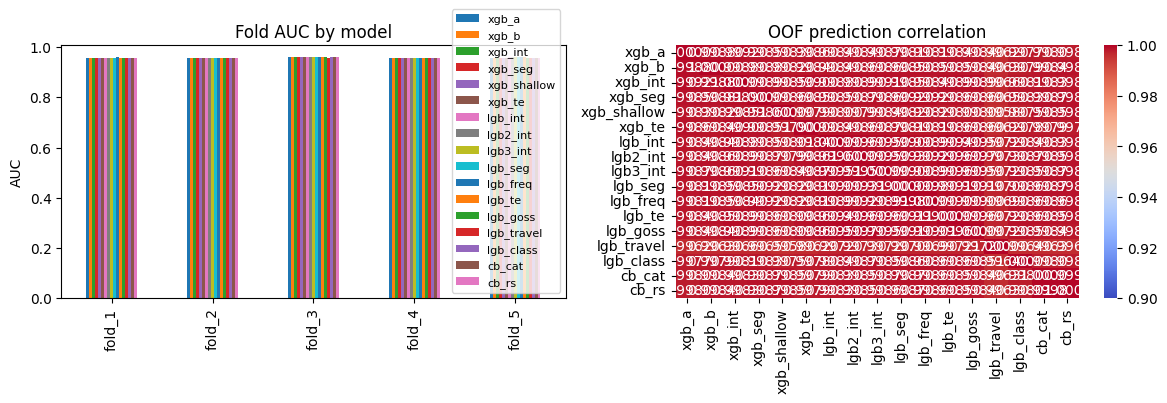

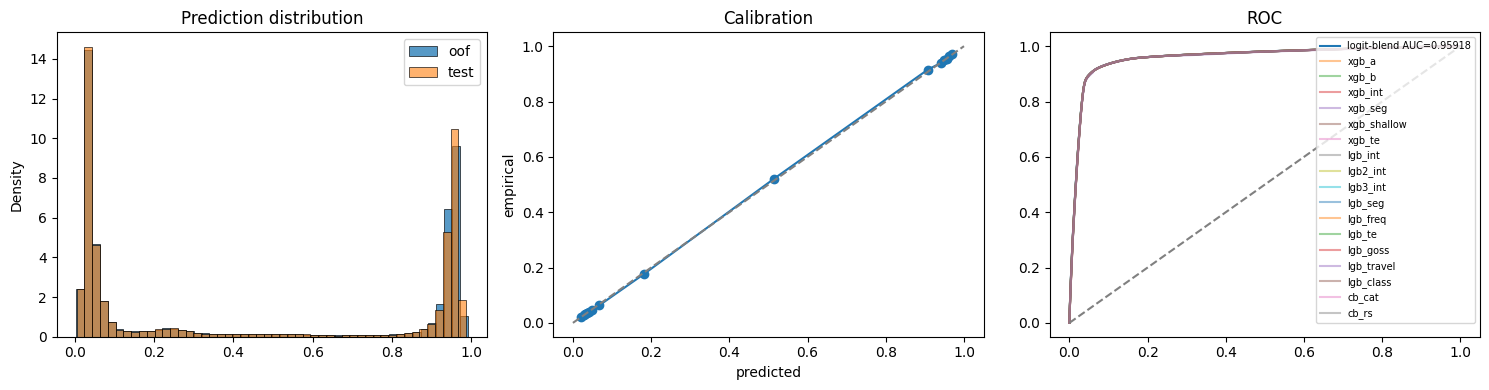

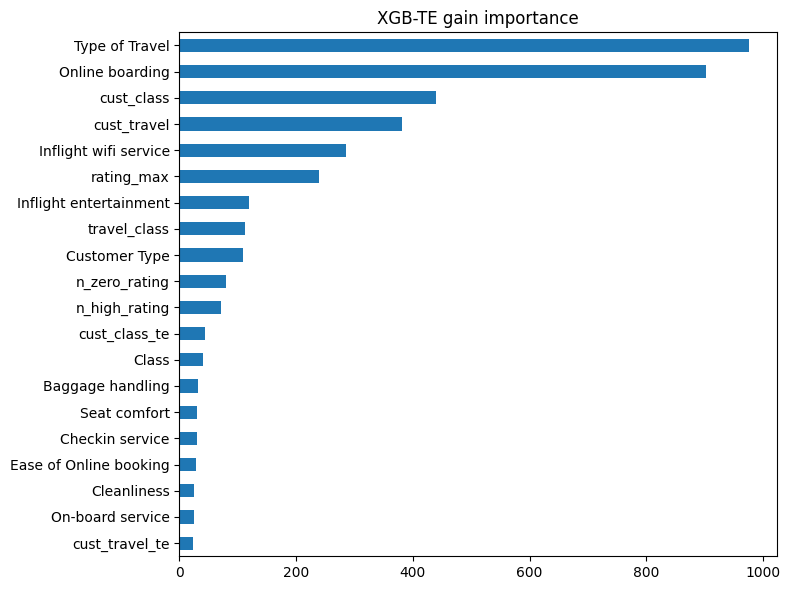

Type of Travel            975.524780
Online boarding           902.756409
cust_class                439.389252
cust_travel               381.454315
Inflight wifi service     286.129303
rating_max                238.899582
Inflight entertainment    118.976105
travel_class              112.139641
Customer Type             108.784599
n_zero_rating              80.560081
n_high_rating              71.161674
cust_class_te              43.046761
Class                      40.935478
Baggage handling           31.854998
Seat comfort               29.823498
Checkin service            29.398447
Ease of Online booking     28.004662
Cleanliness                24.990305
On-board service           24.083080
cust_travel_te             23.743025
dtype: float64

,id,y,oof,abs_error
447771,447771,1,0.003975,0.996025
211257,211257,1,0.005526,0.994474
624095,624095,1,0.008010,0.991990
2951,2951,1,0.008661,0.991339
245703,245703,1,0.009952,0.990048
171002,171002,1,0.010006,0.989994
218804,218804,1,0.010077,0.989923
409576,409576,1,0.010389,0.989611
689712,689712,1,0.010416,0.989584
688464,688464,1,0.010620,0.989380


logit-blend oof auc: 0.959182


In [9]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

fold_auc_df = pd.DataFrame(fold_scores)
fold_auc_df.index = [f"fold_{i}" for i in range(1, n_splits + 1)]
display(fold_auc_df)
display(fold_auc_df.agg(["mean", "std"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fold_auc_df.plot(kind="bar", ax=axes[0])
axes[0].set_ylabel("AUC")
axes[0].set_title("Fold AUC by model")
axes[0].legend(loc="lower right", fontsize=8)

corr_preds = pd.DataFrame({name: oof[name] for name in model_names}).corr()
sns.heatmap(corr_preds, annot=True, fmt=".4f", cmap="coolwarm", ax=axes[1], vmin=0.9, vmax=1.0)
axes[1].set_title("OOF prediction correlation")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(oof_pred, bins=50, stat="density", ax=axes[0], color="C0", label="oof")
sns.histplot(test_pred, bins=50, stat="density", ax=axes[0], color="C1", label="test", alpha=0.6)
axes[0].legend()
axes[0].set_title("Prediction distribution")

prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=15, strategy="quantile")
axes[1].plot(prob_pred, prob_true, marker="o")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("empirical")
axes[1].set_title("Calibration")

fpr, tpr, _ = roc_curve(y, oof_pred)
axes[2].plot(fpr, tpr, label=f"logit-blend AUC={oof_auc:.5f}")
for name in model_names:
    fpr_i, tpr_i, _ = roc_curve(y, oof[name])
    axes[2].plot(fpr_i, tpr_i, alpha=0.45, label=name)
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[2].set_title("ROC")
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

imp = pd.Series(xgb_models_te[0].get_score(importance_type="gain")).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
imp.head(20).iloc[::-1].plot(kind="barh")
plt.title("XGB-TE gain importance")
plt.tight_layout()
plt.show()
display(imp.head(20))

error_df = train[["id"]].copy()
error_df["y"] = y
error_df["oof"] = oof_pred
error_df["abs_error"] = (error_df["y"] - error_df["oof"]).abs()
display(error_df.sort_values("abs_error", ascending=False).head(10))
print(f"logit-blend oof auc: {oof_auc:.6f}")
